In [1]:
import pandas as pd
#df_tmp = pd.read_csv("Allele_results_for_plotting/20240105_comparative_BrainR1R2merged_allele.csv",index_col=0)
df_tmp2 = pd.read_csv("indexing/SNP_haploreg_annotated_20240604.csv",index_col=0)
df_index = pd.read_csv("indexing/index_20240125_curated.csv",index_col="full").drop("allele",axis=1)

import os
for f in os.listdir("Allele_results_for_plotting"):
    if f.endswith("allele.csv") and f.startswith("20"):
        df_tmp = pd.read_csv("Allele_results_for_plotting/"+f,index_col=0)
        df_tmp = pd.merge(df_tmp,df_index,left_index=True,right_index=True,how="left")
        df_tmp = pd.merge(df_tmp,df_tmp2.drop(["Contributor","Type","RSID","nearest_gene","chr"],axis=1),left_index=True,right_index=True,how="left")#df_tmp2["pos_hg38"]
        df_tmp["chr_number"] = df_tmp['chr'].str.slice(3,)
        df_tmp["rsid_gene"] = df_tmp["rsid"]+df_tmp["a1"]+":"+df_tmp["a2"]+" ("+df_tmp["nearest_gene"]+")"
        df_tmp.to_csv("Allele_results_for_plotting/"+"annotated_"+f)##########################

        Pfenning = df_tmp[df_tmp["Contributor"]=="Pfenning"]
        Kellis = df_tmp[df_tmp["Contributor"]=="Kellis"]
        Bertram = df_tmp[df_tmp["Contributor"]=="Bertram"]
        Tanzi = df_tmp[df_tmp["Contributor"]=="Tanzi"]
        Hide = df_tmp[df_tmp["Contributor"]=="Hide"]

        Pfenning.to_csv("For_collaborators/Pfenning/"+f)
        Kellis.to_csv("For_collaborators/Kellis/"+f)
        Bertram.to_csv("For_collaborators/Bertram/"+f)
        Tanzi.to_csv("For_collaborators/Tanzi/"+f)
        Hide.to_csv("For_collaborators/Hide/"+f)

In [48]:
df_tmp = pd.read_csv("Allele_results_for_plotting/20240105_comparative_BrainR1R2merged_allele.csv",index_col=0)
df_tmp2 = pd.read_csv("indexing/SNP_haploreg_annotated_20240417.csv",index_col=0)
df_index = pd.read_csv("indexing/index_20240103_curated.csv",index_col="full").drop("allele",axis=1)

def split_contributor(df_tmp,name):
    df_tmp = pd.merge(df_tmp,df_index,left_index=True,right_index=True,how="left")
    df_tmp = pd.merge(df_tmp,df_tmp2["pos_hg38"],left_index=True,right_index=True,how="left")
    Pfenning = df_tmp[df_tmp["Contributor"]=="Pfenning"]
    Kellis = df_tmp[df_tmp["Contributor"]=="Kellis"]
    Bertram = df_tmp[df_tmp["Contributor"]=="Bertram"]
    Tanzi = df_tmp[df_tmp["Contributor"]=="Tanzi"]
    Hide = df_tmp[df_tmp["Contributor"]=="Hide"]

    Pfenning.to_csv("For_collaborators/Pfenning/"+name)
    Kellis.to_csv("For_collaborators/Kellis/"+name)
    Bertram.to_csv("For_collaborators/Bertram/"+name)
    Tanzi.to_csv("For_collaborators/Tanzi/"+name)
    Hide.to_csv("For_collaborators/Hide/"+name)
                
import os
for f in os.listdir("enhancer_activities"):
    if f.endswith("byAllele"):
        print(f)
        REF = pd.read_csv('enhancer_activities/'+f+"/20240105_MPRA3_MAD_mergedREF.csv",index_col=0)    
        ALT = pd.read_csv('enhancer_activities/'+f+"/20240105_MPRA3_MAD_mergedALT.csv",index_col=0)
        tissue = f.split("_")[0]
        split_contributor(REF,f"20240105_MPRA3_MAD_{tissue}_mergedREF.csv")
        split_contributor(ALT,f"20240105_MPRA3_MAD_{tissue}_mergedALT.csv")

Brain_byAllele
HEK293T_byAllele
HMC3_byAllele
THP1Macrophage_byAllele
THP1Monocyte_byAllele


In [2]:
import pandas as pd

In [60]:
df = pd.read_csv('allele_results_for_plotting/annotated_20240409_comparative_BrainR1R2merged20240404_allele.csv',index_col=0 )
df_snp = df[df["center"]!="MOTIFDISRUPT"]
df_rare_snp = df[(df["Contributor"]=="Tanzi") | (df["Contributor"]=="Hide")]
#df_rare_snp = df[(df["EUR"]<=0.01) | (df["EUR"].isna())]
df_rare_snp = df_rare_snp[(df_rare_snp["EUR"]<=0.01) | (df_rare_snp["EUR"].isna())]
df_common_snp = df[(df["Contributor"]=="Pfenning") | (df["Contributor"]=="Kellis")]
# = df[~((df["EUR"]<=0.01) | (df["EUR"].isna()))]
df_common_snp = df_common_snp[~((df_common_snp["EUR"]<=0.01) | (df_common_snp["EUR"].isna()))]

In [64]:
df_brain = pd.read_csv('allele_results_for_plotting/annotated_20240409_comparative_BrainR1R2merged20240404_allele.csv',index_col=0 )
df_brain= df_brain[df_brain["center"]!="MOTIFDISRUPT"]
df_brain

,statistic,pval,fdr,df.test,df.dna,df.rna.full,df.rna.red,logFC,rsid,center,...,GENCODE_direction,GENCODE_distance,RefSeq_id,RefSeq_name,RefSeq_direction,RefSeq_distance,dbSNP_functional_annotation,query_snp_rsid,Promoter_histone_marks,Enhancer_histone_marks
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,14.352905,0.000152,0.002269,1,11,8,7,0.390049,cg03073402,SNPCENTER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,11.438870,0.000719,0.006596,1,11,8,7,-0.350379,cg03169557,SNPCENTER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,0.388852,0.532904,0.675184,1,11,8,7,0.084761,cg05030077,SNPCENTER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,2.250708,0.133553,0.268690,1,11,8,7,-0.193048,cg05066959,SNPCENTER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,0.063258,0.801418,0.868843,1,11,8,7,-0.053215,cg05228284,SNPCENTER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
alt:rs9478143:PEAKCENTER:chr6:150862035:A:G:150861632:150862271:150862051,4.835366,0.027882,0.092757,1,11,8,7,-0.264014,rs9478143,PEAKCENTER,...,5.0,3513.0,NM_001242769,MTHFD1L,5.0,3642.0,.,rs9478143,BLD,"ESDR, LNG, BLD, SKIN, ADRL, HRT, PLCNT, THYM, ..."
alt:rs953471:PEAKCENTER:chr9:124221903:G:A:124221758:124221963:124221854,5.062834,0.024444,0.087008,1,11,8,7,-0.227581,rs953471,PEAKCENTER,...,5.0,35702.0,NM_001166167,NEK6,5.0,35701.0,.,rs953471,"BLD, LIV","BLD, BRN, SKIN, FAT, GI, LNG, MUS, PLCNT, THYM..."
alt:rs965034941:SNPCENTER:chr19:1999195:CCA:C:1999082:1999308:1999195,6.973607,0.008272,0.038104,1,11,8,7,-0.299938,rs965034941,SNPCENTER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alt:rs983392:PEAKCENTER:chr11:59923508:A:G:59923333:59923833:59923583,0.857024,0.354573,0.523997,1,11,8,7,0.153990,rs983392,PEAKCENTER,...,3.0,3651.0,NM_152852,MS4A6A,3.0,15570.0,.,rs983392,"ESDR, BLD, VAS","BRST, BLD, SKIN"


In [100]:
df_brain = pd.read_csv('allele_results_for_plotting/annotated_20240409_comparative_BrainR1R2merged20240404_allele.csv',index_col=0 )
#df_brain["logFC"]=zscore(abs(df_brain["logFC"]))

df_brain= df_brain[df_brain["center"]!="MOTIFDISRUPT"]

#df_brain =df_brain[df_brain['fdr']<=0.05]
df_brain_rare = df_brain[(df_brain["Contributor"]=="Tanzi") | (df_brain["Contributor"]=="Hide")]
##df_brain_rare = df_brain[(df_brain["EUR"]<=0.01) | (df_brain["EUR"].isna())]
df_brain_rare = df_brain_rare[(df_brain_rare["EUR"]<=0.01) | (df_brain_rare["EUR"].isna())]
df_brain_rare_snp = df_brain_rare[df_brain_rare["center"]!="MOTIFDISRUPT"]
df_brain_common = df_brain[(df_brain["Contributor"]=="Pfenning") | (df_brain["Contributor"]=="Kellis")]
#df_brain_common = df_brain[~((df_brain["EUR"]<=0.01) | (df_brain["EUR"].isna()))]
df_brain_common = df_brain_common[~((df_brain_common["EUR"]<=0.01) | (df_brain_common["EUR"].isna()))]
df_brain_common_snp = df_brain_common[df_brain_common["center"]!="MOTIFDISRUPT"]

df_mac = pd.read_csv('allele_results_for_plotting/annotated_20240129_comparative_THP1Macrophage_allele.csv',index_col=0 )
#df_mac["logFC"]=zscore(abs(df_mac["logFC"]))
#df_mac =df_mac[df_mac['fdr']<=0.05]
df_mac_rare = df_mac[(df_mac["Contributor"]=="Tanzi") | (df_mac["Contributor"]=="Hide")]
##df_mac_rare = df_mac[(df_mac["EUR"]<=0.01) | (df_mac["EUR"].isna())]
df_mac_rare = df_mac_rare[(df_mac_rare["EUR"]<=0.01) | (df_mac_rare["EUR"].isna())]
df_mac_rare_snp = df_mac_rare[df_mac_rare["center"]!="MOTIFDISRUPT"]
df_mac_common = df_mac[(df_mac["Contributor"]=="Pfenning") | (df_mac["Contributor"]=="Kellis")]
#df_mac_common = df_mac[~((df_mac["EUR"]<=0.01) | (df_mac["EUR"].isna()))]
df_mac_common = df_mac_common[~((df_mac_common["EUR"]<=0.01) | (df_mac_common["EUR"].isna()))]
df_mac_common_snp = df_mac_common[df_mac_common["center"]!="MOTIFDISRUPT"]

In [115]:
df_mac_rare_snp.loc[df_brain_rare_snp[df_brain_rare_snp["fdr"]<=0.05].index]

,statistic,pval,fdr,df.test,df.dna,df.rna.full,df.rna.red,logFC,rsid,center,...,GENCODE_direction,GENCODE_distance,RefSeq_id,RefSeq_name,RefSeq_direction,RefSeq_distance,dbSNP_functional_annotation,query_snp_rsid,Promoter_histone_marks,Enhancer_histone_marks
alt:rs11139563:PEAKCENTER:chr9:82410697:T:A:82410144:82410929:82410601,1.157501,0.281984,0.390558,1,53,7,6,0.023074,rs11139563,PEAKCENTER,...,0.0,0.0,NM_001001670,FAM75D1,3.0,415440.0,.,rs11139563,NaN,"ESC, BRST, SKIN, GI, PANC, LNG, BLD"
alt:rs112439188:PEAKCENTER:chr2:103335482:T:C:103335436:103335742:103335517,0.713468,0.398295,0.508738,1,53,7,6,-0.024057,rs112439188,PEAKCENTER,...,5.0,159221.0,NM_144632,TMEM182,3.0,517801.0,.,rs112439188,NaN,NaN
alt:rs113046258:PEAKCENTER:chr19:58183782:A:G:58182601:58184100:58183816,0.304500,0.581075,0.681707,1,53,7,6,-0.009771,rs113046258,PEAKCENTER,...,0.0,0.0,NM_133502,ZNF274,0.0,0.0,INT,rs113046258,"ESC, ESDR, IPSC, FAT, BRST, BLD, MUS, BRN, SKI...",NaN
alt:rs113046258:PEAKCENTER:chr19:58183782:A:G:58182737:58183975:58183741,0.908788,0.340436,0.457813,1,53,7,6,0.019113,rs113046258,PEAKCENTER,...,0.0,0.0,NM_133502,ZNF274,0.0,0.0,INT,rs113046258,"ESC, ESDR, IPSC, FAT, BRST, BLD, MUS, BRN, SKI...",NaN
alt:rs113046258:PEAKCENTER:chr19:58183782:A:T:58182737:58183975:58183741,0.764129,0.382039,0.497581,1,53,7,6,0.016616,rs113046258,PEAKCENTER,...,0.0,0.0,NM_133502,ZNF274,0.0,0.0,INT,rs113046258,"ESC, ESDR, IPSC, FAT, BRST, BLD, MUS, BRN, SKI...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
alt:rs8064456:PEAKCENTER:chr17:3386620:G:T:3386161:3386666:3386529,1.263062,0.261072,0.368105,1,53,7,6,0.037226,rs8064456,PEAKCENTER,...,5.0,280.0,NM_003553,OR1E1,3.0,10844.0,.,rs8064456,"ESC, IPSC, BLD, BRN, FAT, GI, PANC, OVRY, HRT,...","IPSC, SKIN, GI, LNG, HRT"
alt:rs8176357:SNPCENTER:chr14:103124828:G:A:103124485:103124985:103124735,0.572661,0.449203,0.559033,1,53,7,6,-0.016556,rs8176357,SNPCENTER,...,0.0,0.0,NM_006291,TNFAIP2,5.0,1497.0,.,rs8176357,"ESDR, FAT, STRM, BRST, BLD, GI, PANC, MUS, CRV...","ESC, ESDR, LNG, IPSC, BLD, STRM, SKIN, LIV, BR..."
alt:rs8177462:PEAKCENTER:chr19:12736900:C:T:12736814:12737337:12736895,0.275396,0.599735,0.700149,1,53,7,6,0.011235,rs8177462,PEAKCENTER,...,5.0,591.0,NM_004317,ASNA1,5.0,590.0,.,rs8177462,"ESC, ESDR, LNG, IPSC, FAT, STRM, BRST, BLD, MU...","BLD, VAS, PLCNT, GI, SPLN"
alt:rs877973:PEAKCENTER:chr19:44906026:C:T:44905547:44906127:44906017,0.663907,0.415184,0.525693,1,53,7,6,-0.018823,rs877973,PEAKCENTER,...,0.0,0.0,NM_000041,APOE,0.0,0.0,INT,rs877973,"ESC, ESDR, IPSC, FAT, BRST, BLD, BRN, SKIN, LI...","ESDR, BRST, BLD, GI, BRN, HRT, PANC, SPLN, MUS..."


In [121]:
df_mac_rare_snp_siginBrain = df_mac_rare_snp.loc[df_brain_rare_snp[df_brain_rare_snp["fdr"]<=0.05].index]
rare_snp_bothsig = df_mac_rare_snp_siginBrain[df_mac_rare_snp_siginBrain['fdr']<=0.05].index

In [127]:
df = pd.DataFrame([df_mac_rare_snp.loc[rare_snp_bothsig]["logFC"],df_brain_rare_snp.loc[rare_snp_bothsig]["logFC"]]).T
df.columns =["THP1_macrophage","Brain"]

<AxesSubplot: xlabel='logFC', ylabel='Density'>

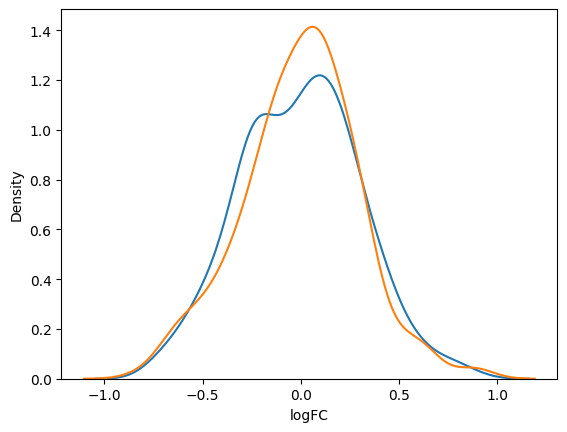

In [108]:
sns.kdeplot(df_brain_rare_snp['logFC'])
sns.kdeplot(df_brain_common_snp['logFC'])

<AxesSubplot: xlabel='logFC', ylabel='Density'>

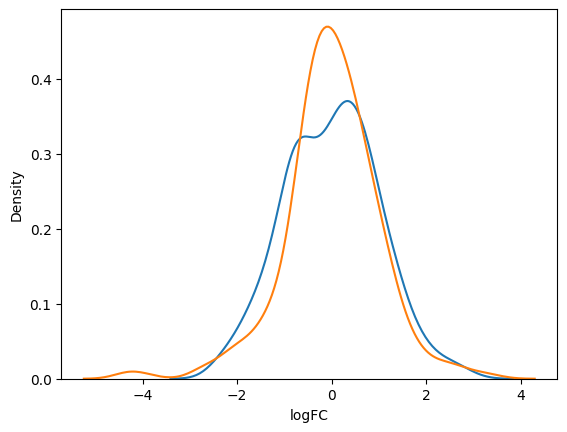

In [130]:
sns.kdeplot(zscore(df_brain_rare_snp['logFC']))
sns.kdeplot(zscore(df_mac_rare_snp['logFC']))

<AxesSubplot: xlabel='logFC', ylabel='Density'>

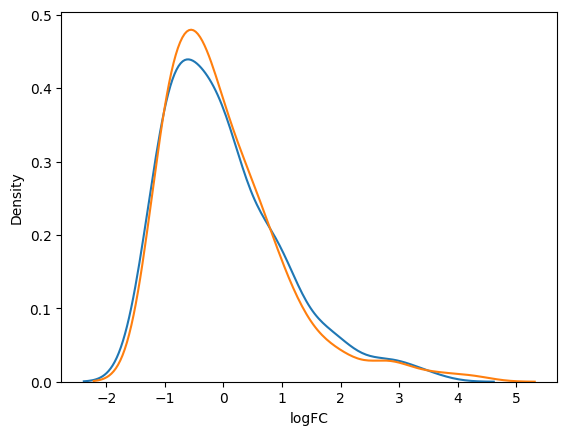

In [135]:
sns.kdeplot(zscore(df_brain_rare_snp[df_brain_rare_snp['logFC']>0]['logFC']))
sns.kdeplot(zscore(df_mac_rare_snp[df_mac_rare_snp['logFC']>0]['logFC']))

In [ ]:

zscore(df_brain_rare_snp['logFC')
# Filter the data
rare_snp_data = df_brain_rare_snp['logFC']>0]['logFC'])
common_snp_data = df_brain_common_snp['logFC']

# Perform the Mann-Whitney U Test
stat, p_value = mannwhitneyu(rare_snp_data, common_snp_data, alternative='two-sided')

# Print the results
print("Mann-Whitney U Test statistic:", stat)
print("P-value:", p_value)

# Check for significance
if p_value < 0.05:
    print("There is a statistically significant difference in logFC between Rare SNP and Common SNP.")
else:
    print("There is no statistically significant difference in logFC between Rare SNP and Common SNP.")

<AxesSubplot: xlabel='logFC', ylabel='Density'>

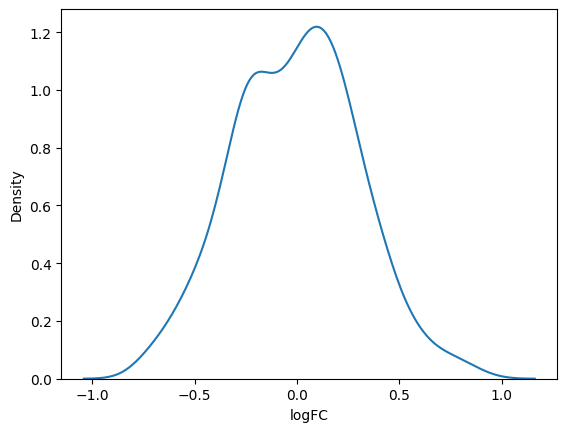

In [102]:
sns.kdeplot(df_brain_rare_snp["logFC"])

<AxesSubplot: xlabel='logFC', ylabel='Density'>

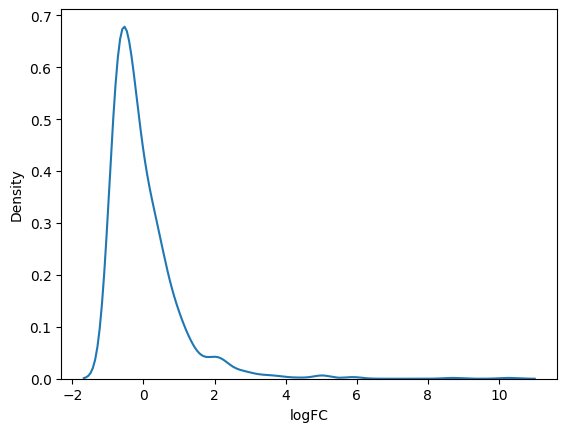

In [99]:
sns.kdeplot(df_mac["logFC"])

<AxesSubplot: xlabel='logFC', ylabel='Density'>

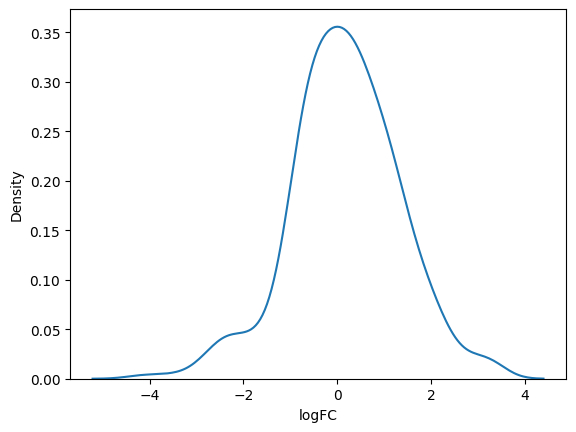

In [92]:
sns.kdeplot(df_brain_rare_snp['logFC']-df_mac_rare_snp['logFC'])

In [94]:
(df_brain_rare_snp['logFC']-df_mac_rare_snp['logFC']).mean()

0.1710875481473684

In [86]:

# Filter the data
rare_snp_data = df_brain_common_snp['logFC']
common_snp_data = df_brain_common_snp['logFC']

# Perform the Mann-Whitney U Test
stat, p_value = mannwhitneyu(rare_snp_data, common_snp_data, alternative='two-sided')

# Print the results
print("Mann-Whitney U Test statistic:", stat)
print("P-value:", p_value)

# Check for significance
if p_value < 0.05:
    print("There is a statistically significant difference in logFC between Rare SNP and Common SNP.")
else:
    print("There is no statistically significant difference in logFC between Rare SNP and Common SNP.")

Mann-Whitney U Test statistic: 45300.5
P-value: 1.0
There is no statistically significant difference in logFC between Rare SNP and Common SNP.


In [78]:
from scipy.stats import zscore

brain_common_mean =df_brain_common_snp['logFC'].mean()# df_brain_common_snp[df_brain_common_snp['logFC']>=0]['logFC'].mean()
mac_common_mean = df_mac_common_snp['logFC'].mean()#[df_mac_common_snp['logFC']>=0]['logFC'].mean()


In [80]:

mac_common_mean

-0.11014829994085915

In [73]:
(zscore(df_brain_rare_snp['logFC']-mac_common_mean)-zscore(df_mac_rare_snp['logFC']-mac_common_mean)).mean()

-6.635815779368752e-17

<AxesSubplot: xlabel='logFC', ylabel='Density'>

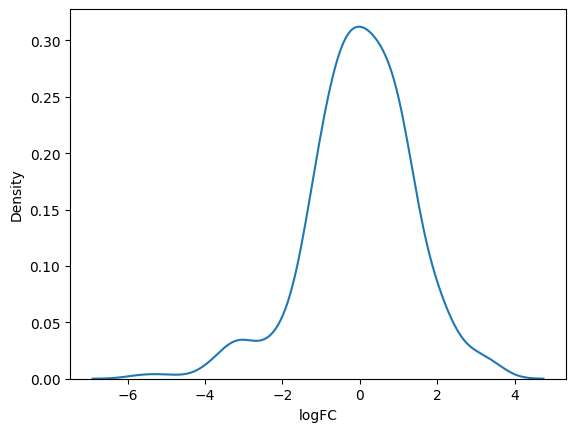

In [68]:
diff = (zscore(df_brain_rare_snp['logFC']-mac_common_mean)-zscore(df_mac_rare_snp['logFC']-mac_common_mean))
sns.kdeplot(diff)

In [69]:
df_brain_rare_snp['logFC']-mac_common_mean

alt:rs10034952:PEAKCENTER:chr4:14137554:A:G:14137502:14138020:14137622         0.127902
alt:rs11139563:PEAKCENTER:chr9:82410697:T:A:82410144:82410929:82410601         0.591550
alt:rs11139563:SNPCENTER:chr9:82410697:T:A:82410144:82410929:82410601          0.344213
alt:rs111469245:SNPCENTER:chr19:8393415:T:A:8393302:8393528:8393415            0.134512
alt:rs111508056:PEAKCENTER:chr3:132659857:T:C:132659366:132660992:132659893    0.010307
                                                                                 ...   
alt:rs877973:PEAKCENTER:chr19:44906026:C:A:44905530:44906110:44905969          0.018764
alt:rs877973:PEAKCENTER:chr19:44906026:C:A:44905547:44906127:44906017          0.158524
alt:rs877973:PEAKCENTER:chr19:44906026:C:T:44905530:44906110:44905969          0.193379
alt:rs877973:PEAKCENTER:chr19:44906026:C:T:44905547:44906127:44906017          0.212919
alt:rs965034941:SNPCENTER:chr19:1999195:CCA:C:1999082:1999308:1999195          0.236543
Name: logFC, Length: 348, dtype:

In [34]:
df_brain_rare_snp[df_brain_rare_snp['logFC']>=0]['logFC']-brain_common_mean

0.060334009421398764

<AxesSubplot: xlabel='logFC', ylabel='Density'>

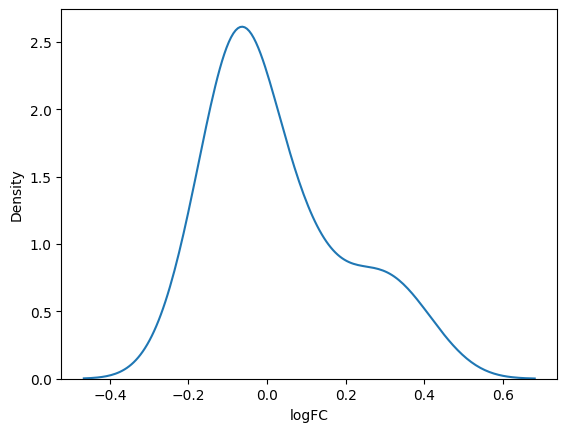

In [29]:
import seaborn as sns
sns.kdeplot(df_brain_rare_snp[df_brain_rare_snp['logFC']>=0]['logFC']-brain_common_mean)

In [11]:
len(df_brain_rare_snp)/len(df_rare_snp)

0.19101123595505617

In [12]:
len(df_brain_common_snp)/len(df_common_snp)

0.2059800664451827

In [59]:
len(df_mac_common_snp)/len(df_common_snp)

0.35584415584415585

In [60]:
len(df_mac_rare_snp)/len(df_rare_snp)

0.34887459807073956

In [63]:
len(df_brain_common_snp.drop_duplicates("RSID"))/len(df_common_snp.drop_duplicates("RSID"))

0.2608695652173913

In [64]:
len(df_brain_rare_snp.drop_duplicates("RSID"))/len(df_rare_snp.drop_duplicates("RSID"))

0.31843575418994413

In [65]:
len(df_mac_common_snp.drop_duplicates("RSID"))/len(df_common_snp.drop_duplicates("RSID"))

0.4826086956521739

In [66]:
len(df_mac_rare_snp.drop_duplicates("RSID"))/len(df_rare_snp.drop_duplicates("RSID"))

0.5027932960893855

In [12]:
df_mac_rare_snp['logFC']
df_mac_common_snp['logFC']

alt:rs1004173:PEAKCENTER:chr6:47445017:C:T:47444925:47446243:47444993     -0.061552
alt:rs1004173:PEAKCENTER:chr6:47445017:C:T:47445015:47446766:47445073      0.050195
alt:rs1010322:PEAKCENTER:chr17:47338083:C:G:47337432:47338428:47338155    -0.100373
alt:rs1010322:PEAKCENTER:chr17:47338083:C:G:47337487:47338325:47338107    -0.295275
alt:rs10130373:PEAKCENTER:chr14:92466231:C:T:92465994:92466494:92466244   -0.046830
                                                                             ...   
alt:rs9271163:PEAKCENTER:chr6:32577733:C:T:32577256:32578131:32577663     -0.182019
alt:rs9271165:PEAKCENTER:chr6:32577785:A:G:32577553:32578053:32577803     -0.062617
alt:rs9271509:PEAKCENTER:chr6:32589415:G:A:32589152:32589652:32589402      0.200503
alt:rs9304646:PEAKCENTER:chr19:44947151:T:A:44946977:44947477:44947227     0.116580
alt:rs9357546:PEAKCENTER:chr6:47549495:C:T:47549371:47549664:47549511     -0.095143
Name: logFC, Length: 137, dtype: float64

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_mac_rare_snp and df_mac_common_snp are already defined and include a 'logFC' column

# Prepare the data
df_mac_rare_snp['SNP_Type'] = 'Rare SNP'
df_mac_common_snp['SNP_Type'] = 'Common SNP'

# Combine the data
combined_data = pd.concat([df_mac_rare_snp[['logFC', 'SNP_Type']], df_mac_common_snp[['logFC', 'SNP_Type']]])
#combined_data = combined_data[combined_data['logFC']<=0]
# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.violinplot(x='SNP_Type', y='logFC', data=combined_data, inner=None)  # Create violin plot without inner annotations
sns.stripplot(x='SNP_Type', y='logFC', data=combined_data, color='k', alpha=0.5, jitter=True, ax=ax)  # Overlay dots

# Enhance plot aesthetics
plt.title('Distribution of logFC for Rare and Common SNPs')
plt.ylabel('logFC')
plt.xlabel('SNP SNP_Type')
plt.grid(True)

# Show the plot
plt.show()

import pandas as pd
from scipy.stats import mannwhitneyu

# Assuming 'combined_data' is your DataFrame and it includes 'logFC' and 'SNP_Type' columns

# Filter the data
rare_snp_data = combined_data[combined_data['SNP_Type'] == "Rare SNP"]['logFC']
common_snp_data = combined_data[combined_data['SNP_Type'] == "Common SNP"]['logFC']

# Perform the Mann-Whitney U Test
stat, p_value = mannwhitneyu(rare_snp_data, common_snp_data, alternative= 'less')

# Print the results
print("Mann-Whitney U Test statistic:", stat)
print("P-value:", p_value)

# Check for significance
if p_value < 0.05:
    print("There is a statistically significant difference in logFC between Rare SNP and Common SNP.")
else:
    print("There is no statistically significant difference in logFC between Rare SNP and Common SNP.")

NameError: name 'df_mac_rare_snp' is not defined

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_mac_rare_snp and df_mac_common_snp are already defined and include a 'logFC' column

# Prepare the data
df_mac_rare_snp['SNP_Type'] = 'Rare SNP'
df_mac_common_snp['SNP_Type'] = 'Common SNP'

# Combine the data
combined_data = pd.concat([df_mac_rare_snp[['logFC', 'SNP_Type']], df_mac_common_snp[['logFC', 'SNP_Type']]])
combined_data = combined_data[combined_data['logFC']>=0]
# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.violinplot(x='SNP_Type', y='logFC', data=combined_data, inner=None)  # Create violin plot without inner annotations
sns.stripplot(x='SNP_Type', y='logFC', data=combined_data, color='k', alpha=0.5, jitter=True, ax=ax)  # Overlay dots

# Enhance plot aesthetics
plt.title('Distribution of logFC for Rare and Common SNPs')
plt.ylabel('logFC')
plt.xlabel('SNP SNP_Type')
plt.grid(True)

# Show the plot
plt.show()

import pandas as pd
from scipy.stats import mannwhitneyu

# Assuming 'combined_data' is your DataFrame and it includes 'logFC' and 'SNP_Type' columns

# Filter the data
rare_snp_data = combined_data[combined_data['SNP_Type'] == "Rare SNP"]['logFC']
common_snp_data = combined_data[combined_data['SNP_Type'] == "Common SNP"]['logFC']

# Perform the Mann-Whitney U Test
stat, p_value = mannwhitneyu(rare_snp_data, common_snp_data, alternative='less')

# Print the results
print("Mann-Whitney U Test statistic:", stat)
print("P-value:", p_value)

# Check for significance
if p_value < 0.05:
    print("There is a statistically significant difference in logFC between Rare SNP and Common SNP.")
else:
    print("There is no statistically significant difference in logFC between Rare SNP and Common SNP.")

NameError: name 'df_mac_rare_snp' is not defined

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_mac_rare_snp and df_mac_common_snp are already defined and include a 'logFC' column

# Prepare the data
df_mac_rare_snp['SNP_Type'] = 'Rare SNP'
df_mac_common_snp['SNP_Type'] = 'Common SNP'

# Combine the data
combined_data = pd.concat([df_mac_rare_snp[['logFC', 'SNP_Type']], df_mac_common_snp[['logFC', 'SNP_Type']]])
combined_data = combined_data[combined_data['logFC']>=0]
# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.violinplot(x='SNP_Type', y='logFC', data=combined_data, inner=None)  # Create violin plot without inner annotations
sns.stripplot(x='SNP_Type', y='logFC', data=combined_data, color='k', alpha=0.5, jitter=True, ax=ax)  # Overlay dots

# Enhance plot aesthetics
plt.title('Distribution of logFC for Rare and Common SNPs')
plt.ylabel('logFC')
plt.xlabel('SNP SNP_Type')
plt.grid(True)

# Show the plot
plt.show()

import pandas as pd
from scipy.stats import mannwhitneyu

# Assuming 'combined_data' is your DataFrame and it includes 'logFC' and 'SNP_Type' columns

# Filter the data
rare_snp_data = combined_data[combined_data['SNP_Type'] == "Rare SNP"]['logFC']
common_snp_data = combined_data[combined_data['SNP_Type'] == "Common SNP"]['logFC']

# Perform the Mann-Whitney U Test
stat, p_value = mannwhitneyu(rare_snp_data, common_snp_data, alternative='less')

# Print the results
print("Mann-Whitney U Test statistic:", stat)
print("P-value:", p_value)

# Check for significance
if p_value < 0.05:
    print("There is a statistically significant difference in logFC between Rare SNP and Common SNP.")
else:
    print("There is no statistically significant difference in logFC between Rare SNP and Common SNP.")

/tmp/ipykernel_246638/1936612050.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_brain_rare_snp['SNP_Type'] = 'Rare SNP'


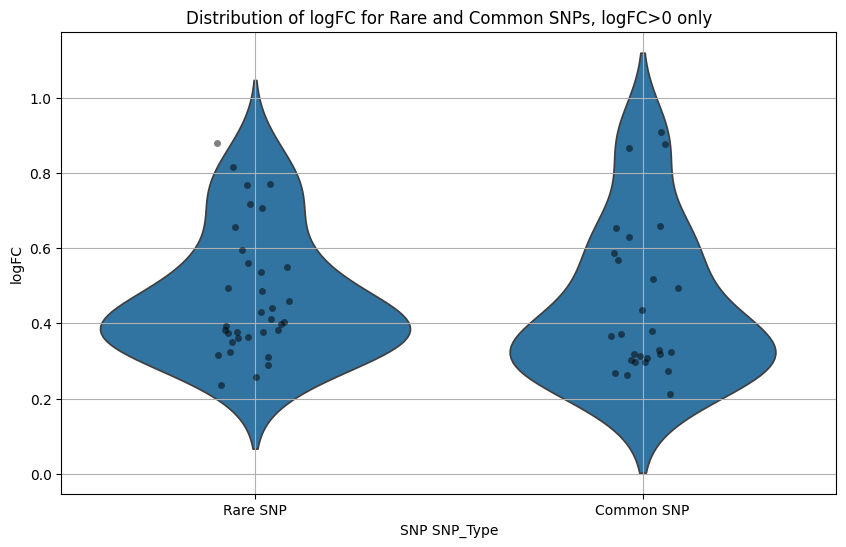

Mann-Whitney U Test statistic: 545.0
P-value: 0.10721433342198855
There is no statistically significant difference in logFC between Rare SNP and Common SNP.


/tmp/ipykernel_246638/1936612050.py:29: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined_data[combined_data['SNP_Type']=="Rare SNP"].mean()
/tmp/ipykernel_246638/1936612050.py:30: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined_data[combined_data['SNP_Type']=="Common SNP"].mean()


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_mac_rare_snp and df_mac_common_snp are already defined and include a 'logFC' column

# Prepare the data
df_brain_rare_snp['SNP_Type'] = 'Rare SNP'
df_brain_common_snp['SNP_Type'] = 'Common SNP'

# Combine the data
combined_data = pd.concat([df_brain_rare_snp[['logFC', 'SNP_Type']], df_brain_common_snp[['logFC', 'SNP_Type']]])
combined_data = combined_data[combined_data['logFC']>=0]
#combined_data['logFC']=abs(combined_data['logFC'])
# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.violinplot(x='SNP_Type', y='logFC', data=combined_data, inner=None)  # Create violin plot without inner annotations
sns.stripplot(x='SNP_Type', y='logFC', data=combined_data, color='k', alpha=0.5, jitter=True, ax=ax)  # Overlay dots

# Enhance plot aesthetics
plt.title('Distribution of logFC for Rare and Common SNPs, logFC>0 only')
plt.ylabel('logFC')
plt.xlabel('SNP SNP_Type')
plt.grid(True)

# Show the plot
plt.show()

combined_data[combined_data['SNP_Type']=="Rare SNP"].mean()
combined_data[combined_data['SNP_Type']=="Common SNP"].mean()
import pandas as pd
from scipy.stats import mannwhitneyu

# Assuming 'combined_data' is your DataFrame and it includes 'logFC' and 'SNP_Type' columns

# Filter the data
rare_snp_data = combined_data[combined_data['SNP_Type'] == "Rare SNP"]['logFC']
common_snp_data = combined_data[combined_data['SNP_Type'] == "Common SNP"]['logFC']

# Perform the Mann-Whitney U Test
stat, p_value = mannwhitneyu(rare_snp_data, common_snp_data, alternative='greater')

# Print the results
print("Mann-Whitney U Test statistic:", stat)
print("P-value:", p_value)

# Check for significance
if p_value < 0.05:
    print("There is a statistically significant difference in logFC between Rare SNP and Common SNP.")
else:
    print("There is no statistically significant difference in logFC between Rare SNP and Common SNP.")


/tmp/ipykernel_205392/1969519683.py:1: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined_data[combined_data['SNP_Type']=="Rare SNP"].mean()


logFC    0.504362
dtype: float64

/tmp/ipykernel_205392/2439408395.py:1: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined_data[combined_data['SNP_Type']=="Common SNP"].mean()


logFC    0.449467
dtype: float64

Mann-Whitney U Test statistic: 770.0
P-value: 0.044863632328328636
There is a statistically significant difference in logFC between Rare SNP and Common SNP.
